In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load all feature files
tickers = ['BHARTIARTL', 'HDFCBANK', 'HINDUNILVR', 'ICICIBANK', 
           'INFY', 'RELIANCE', 'TCS', 'TMPV']

all_features = {}
for ticker in tickers:
    df = pd.read_csv(f'../data/features/{ticker}_features.csv',
                     index_col=0, parse_dates=True)
    all_features[ticker] = df

print("Loaded successfully")
for ticker in tickers:
    print(ticker, all_features[ticker].shape)

Loaded successfully
BHARTIARTL (1814, 6)
HDFCBANK (1814, 6)
HINDUNILVR (1814, 6)
ICICIBANK (1814, 6)
INFY (1814, 6)
RELIANCE (1814, 6)
TCS (1814, 6)
TMPV (1814, 6)


In [2]:
def detect_anomalies(df, ticker, contamination=0.02):
    """
    contamination=0.02 means we expect roughly 2% of days to be anomalous
    (about 36 days out of 1814 — reasonable for 7 years of market data)
    """
    # Select features for anomaly detection
    features = ['daily_return', 'volatility_30', 'rsi_14', 'ma_7', 'ma_30']
    X = df[features].copy()
    
    # Scale features - important since returns are tiny decimals 
    # but RSI is 0-100, IsolationForest needs them on similar scales
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train Isolation Forest
    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42
    )
    model.fit(X_scaled)
    
    # Predict: -1 = anomaly, 1 = normal
    df = df.copy()
    df['anomaly'] = model.predict(X_scaled)
    df['anomaly_score'] = model.decision_function(X_scaled)
    # Convert to readable flag: 1 = anomaly, 0 = normal
    df['is_anomaly'] = (df['anomaly'] == -1).astype(int)
    
    return df, model, scaler

# Test on Reliance first
reliance_anomalies, model_rel, scaler_rel = detect_anomalies(
    all_features['RELIANCE'], 'RELIANCE'
)

print(f"Total anomalies detected: {reliance_anomalies['is_anomaly'].sum()}")
print(f"Anomaly rate: {reliance_anomalies['is_anomaly'].mean()*100:.2f}%")
print("\nSample anomaly dates:")
print(reliance_anomalies[reliance_anomalies['is_anomaly']==1]['daily_return'].head(10))

Total anomalies detected: 37
Anomaly rate: 2.04%

Sample anomaly dates:
Date
2020-03-09   -0.123407
2020-03-12   -0.078497
2020-03-16   -0.081064
2020-03-18   -0.039186
2020-03-19   -0.052452
2020-03-20    0.109240
2020-03-23   -0.131539
2020-03-24    0.067134
2020-03-25    0.147180
2020-03-26   -0.014830
Name: daily_return, dtype: float64


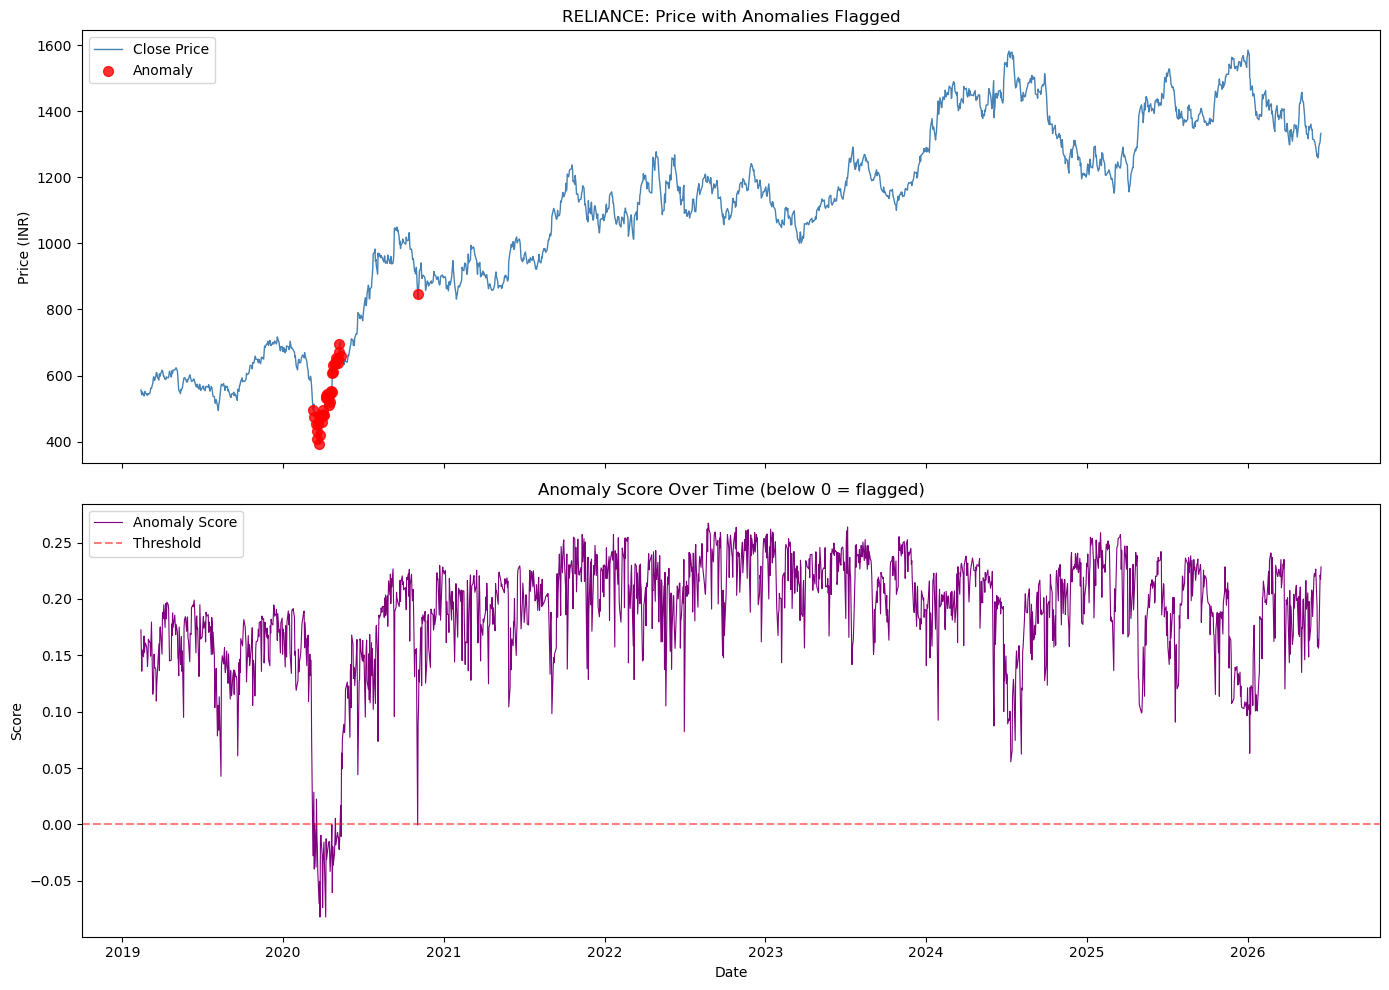

In [3]:
def plot_anomalies(df, ticker):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Top chart: price with anomalies marked
    ax1.plot(df.index, df['close'], label='Close Price', 
             color='steelblue', linewidth=1)
    anomaly_points = df[df['is_anomaly'] == 1]
    ax1.scatter(anomaly_points.index, anomaly_points['close'],
                color='red', s=50, zorder=5, label='Anomaly', alpha=0.8)
    ax1.set_title(f'{ticker}: Price with Anomalies Flagged')
    ax1.set_ylabel('Price (INR)')
    ax1.legend()
    
    # Bottom chart: anomaly score over time
    ax2.plot(df.index, df['anomaly_score'], 
             color='purple', linewidth=0.8, label='Anomaly Score')
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Threshold')
    ax2.set_title('Anomaly Score Over Time (below 0 = flagged)')
    ax2.set_ylabel('Score')
    ax2.set_xlabel('Date')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_anomalies(reliance_anomalies, 'RELIANCE')

In [4]:
all_anomalies = {}

for ticker in tickers:
    df_anomaly, _, _ = detect_anomalies(all_features[ticker], ticker)
    all_anomalies[ticker] = df_anomaly
    count = df_anomaly['is_anomaly'].sum()
    
    # Show top anomaly dates by most extreme return
    top_dates = df_anomaly[df_anomaly['is_anomaly']==1]['daily_return'].abs().nlargest(3)
    print(f"{ticker}: {count} anomalies | Top dates: {list(top_dates.index.strftime('%Y-%m-%d'))}")

BHARTIARTL: 37 anomalies | Top dates: ['2020-03-23', '2020-05-19', '2020-04-07']
HDFCBANK: 37 anomalies | Top dates: ['2020-03-23', '2020-03-25', '2020-04-07']
HINDUNILVR: 37 anomalies | Top dates: ['2020-04-07', '2020-03-20', '2020-03-23']
ICICIBANK: 37 anomalies | Top dates: ['2020-03-23', '2020-04-07', '2020-05-04']
INFY: 37 anomalies | Top dates: ['2019-10-22', '2020-03-24', '2020-03-23']
RELIANCE: 37 anomalies | Top dates: ['2020-03-25', '2020-03-23', '2020-03-09']
TCS: 37 anomalies | Top dates: ['2020-03-20', '2020-03-12', '2026-06-03']
TMPV: 37 anomalies | Top dates: ['2025-10-14', '2021-10-13', '2020-04-30']


In [5]:
# Investigate TCS June 2026 anomaly
tcs_df = all_anomalies['TCS']
june_2026 = tcs_df.loc['2026-06-01':'2026-06-10']
print(june_2026[['close', 'daily_return', 'volatility_30', 'is_anomaly']])

                  close  daily_return  volatility_30  is_anomaly
Date                                                            
2026-06-01  2297.399902      0.017044       0.015760           0
2026-06-02  2446.899902      0.065074       0.019956           0
2026-06-03  2241.699951     -0.083861       0.024597           1
2026-06-04  2241.000000     -0.000312       0.024595           0
2026-06-05  2198.899902     -0.018786       0.023199           0
2026-06-08  2151.399902     -0.021602       0.023030           0
2026-06-09  2151.000000     -0.000186       0.023034           0
2026-06-10  2153.899902      0.001348       0.022861           0
